In [2]:
import pandas as pd

df = pd.read_csv('coursework_AI_ethics_hiring_data.csv')
df

,id,age,age_group,gender,education,experience,graduation_year,outdated_vocab,hobby,youth_hobby,model_score,model_decision,true_success,historical_success
0,1,56,45+,1,3,24,1988.0,1,садоводство,0,0.227043,0,1,0
1,2,46,45+,0,2,21,2001.0,0,путешествия,0,0.388544,0,1,0
2,3,32,30-45,0,1,9,2016.0,1,фотография,0,0.353160,0,1,1
3,4,60,45+,1,2,25,1982.0,1,вязание,0,0.140580,0,0,0
4,5,25,<30,1,3,9,2022.0,1,видеоигры,1,0.788198,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,<30,0,3,0,2017.0,0,путешествия,0,0.700203,1,0,1
4996,4997,47,45+,1,1,21,2002.0,1,чтение,0,0.241924,0,0,0
4997,4998,18,<30,1,3,0,2009.0,0,фотография,0,0.677227,1,1,1
4998,4999,47,45+,1,3,12,2003.0,0,рыбалка,0,0.577197,1,1,0


In [5]:
df.age_group.value_counts()

age_group
45+      2093
30-45    1576
<30      1331
Name: count, dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   age_group           5000 non-null   str    
 3   gender              5000 non-null   int64  
 4   education           5000 non-null   int64  
 5   experience          5000 non-null   int64  
 6   graduation_year     5000 non-null   float64
 7   outdated_vocab      5000 non-null   int64  
 8   hobby               5000 non-null   str    
 9   youth_hobby         5000 non-null   int64  
 10  model_score         5000 non-null   float64
 11  model_decision      5000 non-null   int64  
 12  true_success        5000 non-null   int64  
 13  historical_success  5000 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 547.0 KB


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Предполагается, что DataFrame уже загружен в переменную df
# 1. Сводная статистика по возрастным группам
age_stats = df.groupby('age_group').agg(
    mean_score=('model_score', 'mean'),
    median_score=('model_score', 'median'),
    invitation_rate=('model_decision', 'mean'),
    count=('id', 'count')
).reset_index()

print("📊 Сводная статистика по возрастным группам:")
print(age_stats.round(3))

# 2. Проверка статистической значимости различий в оценках модели
# Используем тест Крускала-Уоллиса, так как распределение оценок часто не нормальное
groups = [df[df['age_group'] == g]['model_score'].values for g in df['age_group'].unique()]
h_stat, p_value = stats.kruskal(*groups)
print(f"\n🔍 Тест Крускала-Уоллиса: H={h_stat:.4f}, p-value={p_value:.2e}")
if p_value < 0.05:
    print("✅ Вывод: Различия в оценках между возрастными группами статистически значимы.")
else:
    print("❌ Вывод: Статистически значимых различий не обнаружено.")

📊 Сводная статистика по возрастным группам:
  age_group  mean_score  median_score  invitation_rate  count
0     30-45       0.481         0.479            0.468   1576
1       45+       0.247         0.218            0.038   2093
2       <30       0.705         0.718            0.941   1331

🔍 Тест Крускала-Уоллиса: H=3377.6175, p-value=0.00e+00
✅ Вывод: Различия в оценках между возрастными группами статистически значимы.


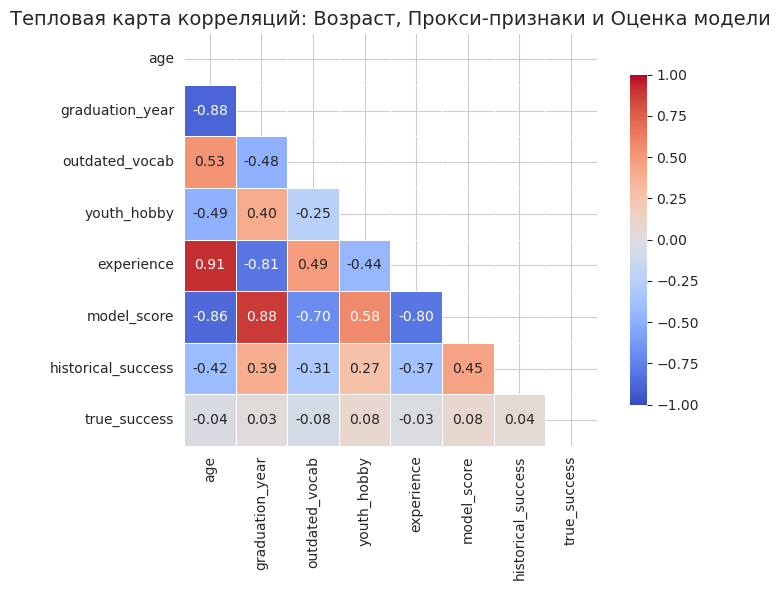

🔑 Ключевые корреляции с возрастом (age):
   с годом окончания вуза (graduation_year): -0.884
   с устаревшей лексикой (outdated_vocab): 0.526
   с опытом работы (experience): 0.913

🔑 Влияние прокси на оценку модели (model_score):
   graduation_year -> model_score: 0.878
   outdated_vocab -> model_score: -0.699


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Выбираем только релевантные для анализа колонки
# age: целевой защищаемый признак
# graduation_year, outdated_vocab, youth_hobby, experience: потенциальные прокси
# model_score: выход модели (на что влияет прокси)
cols_for_heatmap = ['age', 'graduation_year', 'outdated_vocab', 'youth_hobby', 'experience', 'model_score', 'historical_success', 'true_success']

# Создаем подвыборку
df_subset = df[cols_for_heatmap]

# 2. Рассчитываем матрицу корреляции Пирсона
corr_matrix = df_subset.corr()

# 3. Настраиваем визуализацию
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Маска для скрытия верхней треугольной части (для чистоты)

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,          # Показывать значения коэффициентов
            fmt=".2f",           # Формат чисел (2 знака после запятой)
            cmap='coolwarm',     # Цветовая схема (синий - отрицательная, красный - положительная)
            vmin=-1, vmax=1,     # Границы шкалы
            center=0,            # Центрирование цвета на 0
            square=True,         # Квадратные ячейки
            linewidths=.5,       # Линии между ячейками
            cbar_kws={"shrink": .8}) # Размер легенды

plt.title('Тепловая карта корреляций: Возраст, Прокси-признаки и Оценка модели', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Вывод ключевых значений для текстового отчета
print("🔑 Ключевые корреляции с возрастом (age):")
print(f"   с годом окончания вуза (graduation_year): {corr_matrix.loc['age', 'graduation_year']:.3f}")
print(f"   с устаревшей лексикой (outdated_vocab): {corr_matrix.loc['age', 'outdated_vocab']:.3f}")
print(f"   с опытом работы (experience): {corr_matrix.loc['age', 'experience']:.3f}")
print(f"\n🔑 Влияние прокси на оценку модели (model_score):")
print(f"   graduation_year -> model_score: {corr_matrix.loc['graduation_year', 'model_score']:.3f}")
print(f"   outdated_vocab -> model_score: {corr_matrix.loc['outdated_vocab', 'model_score']:.3f}")

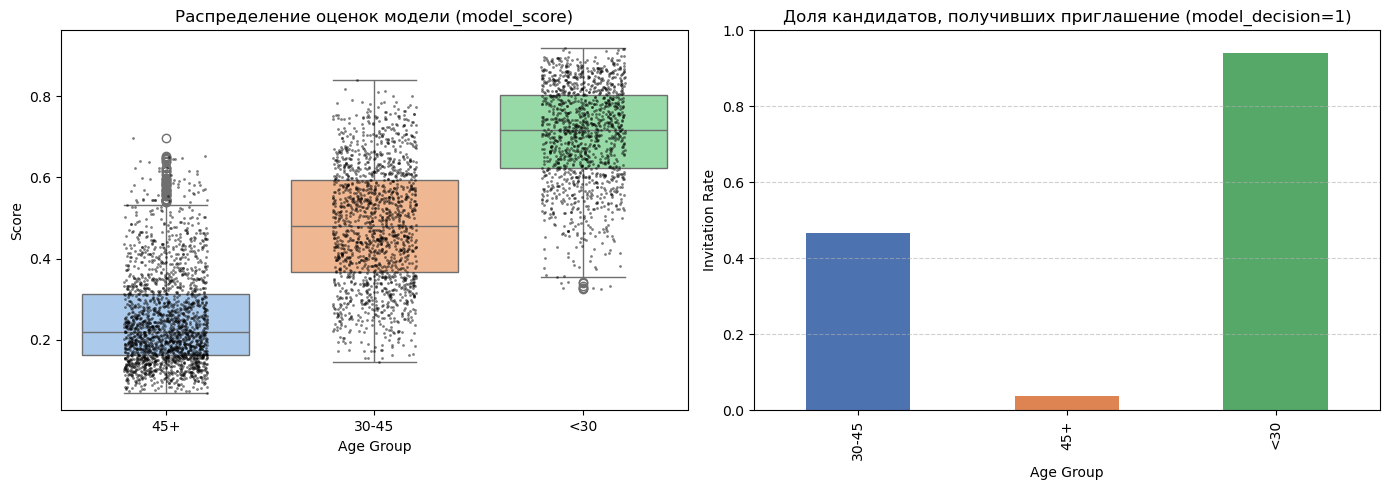

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение оценок по группам (boxplot + swarmplot для плотности)
sns.boxplot(data=df, x='age_group', hue='age_group', legend=False, y='model_score', ax=axes[0], palette='pastel')
# sns.swarmplot(data=df, x='age_group', y='model_score', ax=axes[0], color='black', size=2, alpha=0.5)
sns.stripplot(data=df, x='age_group', y='model_score', ax=axes[0], color='black', size=2, alpha=0.5, jitter=0.2)
axes[0].set_title('Распределение оценок модели (model_score)')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Age Group')

# Доля приглашений на интервью
age_decision = df.groupby('age_group')['model_decision'].mean()
age_decision.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
axes[1].set_title('Доля кандидатов, получивших приглашение (model_decision=1)')
axes[1].set_ylabel('Invitation Rate')
axes[1].set_xlabel('Age Group')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

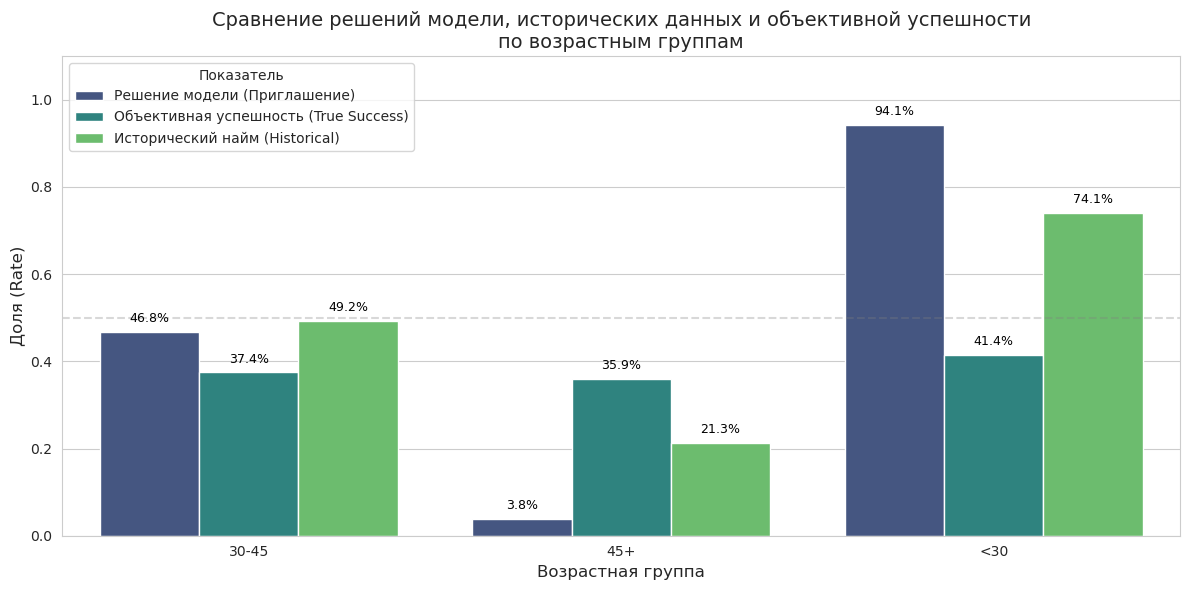


📊 Детальные показатели по возрастным группам:
age_group  model_invitation_rate  true_success_rate  historical_hire_rate
    30-45                  0.468              0.374                 0.492
      45+                  0.038              0.359                 0.213
      <30                  0.941              0.414                 0.741


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Агрегация данных по возрастным группам для всех трех метрик
# mean() для бинарных колонок (0/1) дает долю единиц (вероятность/процент)
metrics_by_age = df.groupby('age_group').agg(
    model_invitation_rate=('model_decision', 'mean'),
    true_success_rate=('true_success', 'mean'),
    historical_hire_rate=('historical_success', 'mean')
).reset_index()

# Для красивого отображения на графике зададим порядок категорий (если нужно)
# age_order = ['<30', '30-45', '45+']
# metrics_by_age['age_group'] = pd.Categorical(metrics_by_age['age_group'], categories=age_order, ordered=True)

# 2. Преобразование таблицы для удобного построения seaborn barplot
# Метод melt превращает широкие колонки в длинные (переменная и значение)
plot_data = metrics_by_age.melt(id_vars='age_group', 
                                var_name='Metric', 
                                value_name='Rate')

# Переименуем метрики для легенды на русский/понятный язык
label_map = {
    'model_invitation_rate': 'Решение модели (Приглашение)',
    'true_success_rate': 'Объективная успешность (True Success)',
    'historical_hire_rate': 'Исторический найм (Historical)'
}
plot_data['Metric_Label'] = plot_data['Metric'].map(label_map)

# 3. Построение графика
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Используем barplot с hue для группировки
bar_plot = sns.barplot(data=plot_data, x='age_group', y='Rate', hue='Metric_Label', palette='viridis')

# Добавляем значения процентов на столбцы для наглядности
for p in bar_plot.patches:
    height = p.get_height()
    if height > 0: # Не подписываем нули, чтобы не засорять график
        bar_plot.annotate(f'{height:.1%}', 
                          (p.get_x() + p.get_width() / 2., height),
                          ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                          textcoords='offset points')

plt.title('Сравнение решений модели, исторических данных и объективной успешности\nпо возрастным группам', fontsize=14)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля (Rate)', fontsize=12)
plt.ylim(0, 1.1) # Немного запаса сверху для подписей
plt.legend(title='Показатель', loc='upper left')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3) # Референсная линия

plt.tight_layout()
plt.show()

# 4. Вывод числовых значений для отчета (копировать в аналитическую записку)
print("\n📊 Детальные показатели по возрастным группам:")
print(metrics_by_age.round(3).to_string(index=False))

🔗 Матрица корреляций (возраст, оценка модели, прокси-признаки):
                   age  model_score  graduation_year  outdated_vocab  \
age              1.000       -0.863           -0.884           0.526   
model_score     -0.863        1.000            0.878          -0.699   
graduation_year -0.884        0.878            1.000          -0.482   
outdated_vocab   0.526       -0.699           -0.482           1.000   
youth_hobby     -0.485        0.576            0.399          -0.246   
experience       0.913       -0.805           -0.807           0.485   

                 youth_hobby  experience  
age                   -0.485       0.913  
model_score            0.576      -0.805  
graduation_year        0.399      -0.807  
outdated_vocab        -0.246       0.485  
youth_hobby            1.000      -0.438  
experience            -0.438       1.000  

⚖️ Средняя разница в score между группами 45+ и <30 при одинаковом образовании и опыте: -0.3162


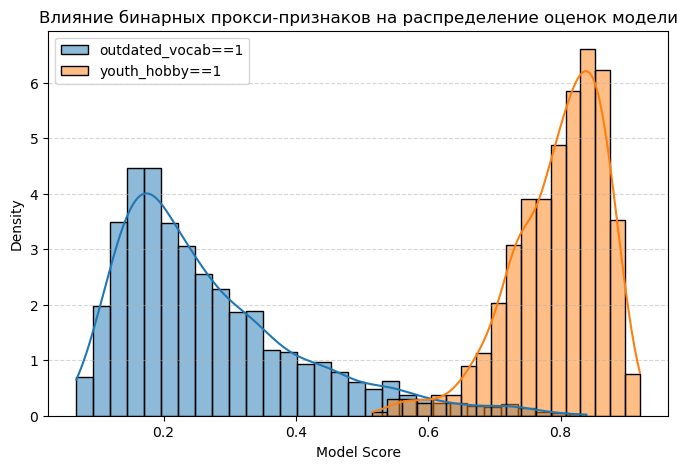

In [7]:
# Список потенциальных прокси-переменных для возраста
proxy_vars = ['graduation_year', 'outdated_vocab', 'youth_hobby', 'experience']

# 1. Корреляция прокси с возрастом и с оценкой модели
corr_matrix = df[['age', 'model_score'] + proxy_vars].corr()
print("🔗 Матрица корреляций (возраст, оценка модели, прокси-признаки):")
print(corr_matrix.round(3))

# 2. Условный анализ: влияет ли возраст на оценку при контроле образования и опыта?
# Группируем по education и experience, смотрим на разницу в score между <30 и 45+
controlled_bias = (df.groupby(['education', 'experience'])
                   .apply(lambda x: x[x['age_group']=='45+']['model_score'].mean() - 
                                      x[x['age_group']=='<30']['model_score'].mean())
                   .dropna().mean())
print(f"\n⚖️ Средняя разница в score между группами 45+ и <30 при одинаковом образовании и опыте: {controlled_bias:.4f}")

# 3. Визуализация влияния прокси
plt.figure(figsize=(8, 5))
for var in ['outdated_vocab', 'youth_hobby']:
    subset = df[df[var] == 1] if var in ['outdated_vocab', 'youth_hobby'] else df
    sns.histplot(data=subset, x='model_score', kde=True, label=f'{var}==1', stat='density', alpha=0.5)
plt.title('Влияние бинарных прокси-признаков на распределение оценок модели')
plt.xlabel('Model Score')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [8]:
# Демографический паритет: разница в вероятности получения приглашения
dp_diff = age_decision['<30'] - age_decision['45+']
print(f"📉 Нарушение демографического паритета (Δ <30 vs 45+): {dp_diff:.3f}")

# Равные возможности (Equal Opportunity): TPR по группам
tp_rates = df.groupby('age_group').apply(lambda x: x[(x['model_decision']==1) & (x['true_success']==1)].shape[0] / 
                                                  x[x['true_success']==1].shape[0] if x[x['true_success']==1].shape[0]>0 else 0)
print(f"\n🎯 True Positive Rate по группам:\n{tp_rates.round(3)}")
eo_diff = tp_rates['<30'] - tp_rates['45+']
print(f"Нарушение равных возможностей (Δ <30 vs 45+): {eo_diff:.3f}")

📉 Нарушение демографического паритета (Δ <30 vs 45+): 0.903

🎯 True Positive Rate по группам:
age_group
30-45    0.508
45+      0.057
<30      0.947
dtype: float64
Нарушение равных возможностей (Δ <30 vs 45+): 0.890
